<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-4/YZ50Hafta4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [697]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [698]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

print("names.txt is downloaded")

names.txt is downloaded


In [699]:
words = open("names.txt", 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

In [700]:
num_vocab = len(chars)
context_size = 3
emb_dim = 2
hidden_dim = 100
batch_size = 32

In [701]:
X, Y = [], []

for word in words:
    context = [0] * context_size
    for ch in word + '.':
        idx = stoi[ch]
        X.append(context)
        Y.append(idx)
        context = context[1:] + [idx]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [702]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

In [703]:
emb = C[X]
emb.shape
hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
logits = hidden_layer @ weight2 + bias2

counts = logits.exp()
probs = counts / counts.sum(dim=1, keepdim=True)
manual_loss = -probs[torch.arange(len(X)), Y].log().mean()

cross_entropy_loss = F.cross_entropy(logits, Y)

print(f"Elle hesaplanan loss: {manual_loss.item()} | Cross entropy ile hesaplanan loss: {cross_entropy_loss}")

Elle hesaplanan loss: 16.72646713256836 | Cross entropy ile hesaplanan loss: 16.726470947265625


In [704]:
for param in parameters:
    param.requires_grad = True

In [705]:
temp_X = X[:32]
temp_Y = Y[:32]

epochs = 100
learning_rate = 0.1

for epoch in range(epochs):
    emb = C[temp_X]
    hidden_layer = torch.tanh(emb.reshape(len(temp_X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, temp_Y)
    if epoch % 10 == 0:
        print(f"Epochs: {epoch} | Loss: {loss}")

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

Epochs: 0 | Loss: 17.775842666625977
Epochs: 10 | Loss: 4.3454132080078125
Epochs: 20 | Loss: 1.2727065086364746
Epochs: 30 | Loss: 0.4890214204788208
Epochs: 40 | Loss: 0.3547118902206421
Epochs: 50 | Loss: 0.32074666023254395
Epochs: 60 | Loss: 0.30477234721183777
Epochs: 70 | Loss: 0.2951887845993042
Epochs: 80 | Loss: 0.28871577978134155
Epochs: 90 | Loss: 0.284017413854599
0.28075531125068665


In [706]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [707]:
epochs = 5000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.4132208824157715


In [708]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [709]:
lr_exp = torch.linspace(-3, 0, 2000)
lr_vals = 10**lr_exp

In [710]:
epochs = 2000
# learning_rate = 0.1

lrs_used = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    learning_rate = lr_vals[epoch]
    lrs_used.append(lr_exp[epoch])
    loss_vals.append(loss.item())

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

7.209765911102295


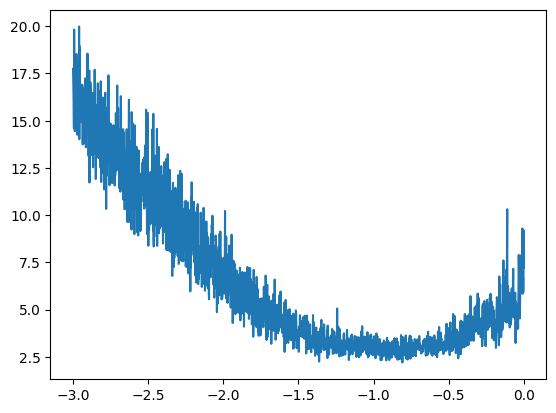

In [711]:
plt.plot(lrs_used, loss_vals);

In [712]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [713]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

1.8638074398040771


In [714]:
def get_entire_data_loss():
    idx = torch.randint(0, len(X), (batch_size,))
    emb = C[X]
    hidden_layer = torch.tanh(emb.reshape(len(X), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print(get_entire_data_loss())

2.3451383113861084


In [715]:
import random

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

random.seed(42)
words_copy = words.copy()
random.shuffle(words_copy)
tr_split = int(0.8 * len(words_copy))
dev_split = int(0.9 * len(words_copy))

Xtr, Ytr = build_dataset(words_copy[:tr_split])
Xdev, Ydev = build_dataset(words_copy[tr_split:dev_split])
Xte, Yte = build_dataset(words_copy[dev_split:])

def get_loss(split):
    x, y = {
        "train": {Xtr, Ytr},
        "dev": {Xdev, Ydev},
        "test": {Xte, Yte},
    }[split]
    emb = C[x]
    hidden_layer = torch.tanh(emb.reshape(len(x), -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, y)
    return loss.item()

In [716]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [717]:
epochs = 30000
learning_rate = 0.1

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

print(loss.item())

2.2950246334075928


In [718]:
print(get_loss("dev"))

2.3449366092681885


In [719]:
print(get_loss("test"))

2.3441569805145264


In [720]:
hidden_dim = 300

In [721]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [722]:
epochs = 30000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.item())

    if epoch > 20000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

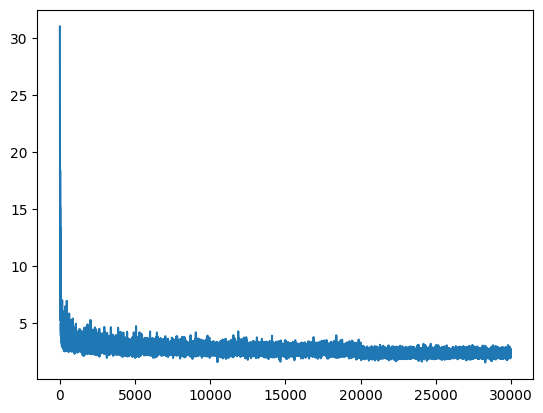

In [723]:
plt.plot(epoch_vals, loss_vals);

In [724]:
print(get_loss("train"))

2.327204942703247


In [725]:
print(get_loss("dev"))

2.329214572906494


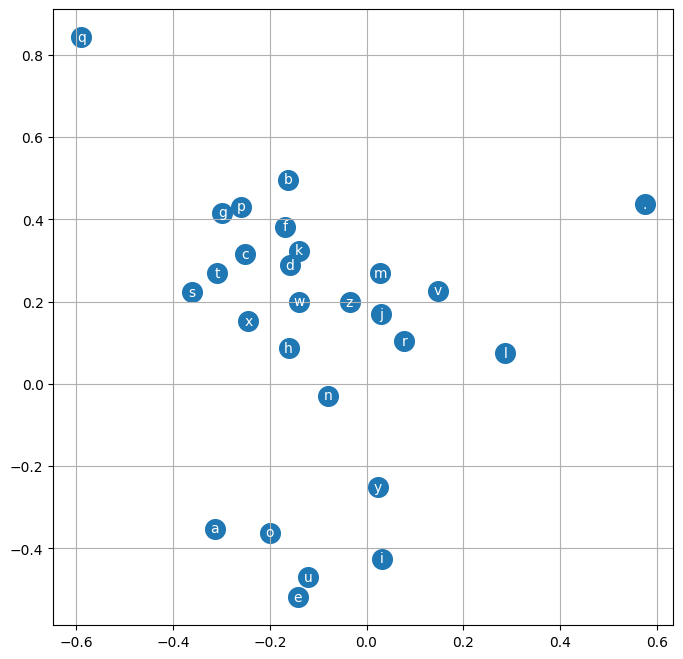

In [726]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(len(C)):
    plt.text(C[i,0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor');

In [727]:
hidden_dim = 200
emb_dim = 10

In [731]:
g = torch.Generator().manual_seed(42)

C = torch.randn((num_vocab, emb_dim),                           generator=g)
weight1 = torch.randn((context_size * emb_dim, hidden_dim),     generator=g)
bias1 = torch.randn((hidden_dim,),                              generator=g)
weight2 = torch.randn((hidden_dim, num_vocab),                  generator=g)
bias2 = torch.randn((num_vocab,),                               generator=g)
parameters = [C, weight1, bias1, weight2, bias2]

for param in parameters:
    param.requires_grad = True

In [732]:
epochs = 100000
learning_rate = 0.1
epoch_vals = []
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    emb = C[Xtr[idx]]
    hidden_layer = torch.tanh(emb.reshape(batch_size, -1) @ weight1 + bias1)
    logits = hidden_layer @ weight2 + bias2
    loss = F.cross_entropy(logits, Ytr[idx])

    for param in parameters:
        param.grad = None

    loss.backward()

    epoch_vals.append(epoch)
    loss_vals.append(loss.log10().item())

    if epoch > 50000:
        learning_rate = 0.01

    for param in parameters:
        param.data += -learning_rate * param.grad

In [733]:
get_loss("train"), get_loss("dev"), get_loss("test")

(2.168355703353882, 2.18863582611084, 2.1857779026031494)

In [735]:
num_names = 20

g = torch.Generator().manual_seed(42)

for _ in range(num_names):
    name = []
    context = [0] * context_size
    while True:
        emb = C[torch.tensor(context)]
        hidden_layer = torch.tanh(emb.reshape(1, -1) @ weight1 + bias1)
        logits = hidden_layer @ weight2 + bias2
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1, generator=g).item()

        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

anuelen
tis
marian
davius
amillayley
kemarcon
anne
jackolaniem
chan
charondre
kalla
mikh
yana
cveria
achalani
carlephel
mar
tal
selari
davoriah
